In [1]:
import pandas as pd

In [2]:
movies=pd.read_csv('dataset.csv')

In [3]:
movies.head(10)

,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,1994-09-23,8.7,21862
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,1995-10-19,8.7,3731
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,1972-03-14,8.7,16280
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,1993-12-15,8.6,12959
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,1974-12-20,8.6,9811
5,667257,Impossible Things,"Family,Drama",es,"Matilde is a woman who, after the death of her...",14.358,2021-06-17,8.6,255
6,129,Spirited Away,"Animation,Family,Fantasy",ja,"A young girl, Chihiro, becomes trapped in a st...",92.056,2001-07-20,8.5,13093
7,730154,Your Eyes Tell,"Romance,Drama",ja,"A tragic accident lead to Kaori's blindness, b...",51.345,2020-10-23,8.5,339
8,372754,Dou kyu sei – Classmates,"Romance,Animation",ja,"Rihito Sajo, an honor student with a perfect s...",14.285,2016-02-20,8.5,239
9,372058,Your Name.,"Romance,Animation,Drama",ja,High schoolers Mitsuha and Taki are complete s...,158.270,2016-08-26,8.5,8895


In [4]:
movies.describe()

,id,popularity,vote_average,vote_count
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,161243.505000,34.697267,6.621150,1547.309400
std,211422.046043,211.684175,0.766231,2648.295789
min,5.000000,0.600000,4.600000,200.000000
25%,10127.750000,9.154750,6.100000,315.000000
50%,30002.500000,13.637500,6.600000,583.500000
75%,310133.500000,25.651250,7.200000,1460.000000
max,934761.000000,10436.917000,8.700000,31917.000000


In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   title              10000 non-null  object 
 2   genre              9997 non-null   object 
 3   original_language  10000 non-null  object 
 4   overview           9987 non-null   object 
 5   popularity         10000 non-null  float64
 6   release_date       10000 non-null  object 
 7   vote_average       10000 non-null  float64
 8   vote_count         10000 non-null  int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 703.3+ KB


In [6]:
movies.isnull().sum()

id                    0
title                 0
genre                 3
original_language     0
overview             13
popularity            0
release_date          0
vote_average          0
vote_count            0
dtype: int64

Feature Selection Part

In [7]:
movies.columns

Index(['id', 'title', 'genre', 'original_language', 'overview', 'popularity',
       'release_date', 'vote_average', 'vote_count'],
      dtype='object')

In [8]:
movies=movies[['id', 'title', 'overview', 'genre']]

In [9]:
movies['overview'] = movies['overview'].fillna('')
movies['genre']    = movies['genre'].fillna('')

In [10]:
movies

,id,title,overview,genre
0,278,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,"Drama,Crime"
1,19404,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...","Comedy,Drama,Romance"
2,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...","Drama,Crime"
3,424,Schindler's List,The true story of how businessman Oskar Schind...,"Drama,History,War"
4,240,The Godfather: Part II,In the continuing saga of the Corleone crime f...,"Drama,Crime"
...,...,...,...,...
9995,10196,The Last Airbender,"The story follows the adventures of Aang, a yo...","Action,Adventure,Fantasy"
9996,331446,Sharknado 3: Oh Hell No!,The sharks take bite out of the East Coast whe...,"Action,TV Movie,Science Fiction,Comedy,Adventure"
9997,13995,Captain America,"During World War II, a brave, patriotic Americ...","Action,Science Fiction,War"
9998,2312,In the Name of the King: A Dungeon Siege Tale,A man named Farmer sets out to rescue his kidn...,"Adventure,Fantasy,Action,Drama"


In [11]:
movies['genre'] = movies['genre'].str.replace(',', ' ')  # "Drama,Crime" → "Drama Crime"
movies['tags']  = movies['overview'] + ' ' + movies['genre']

In [12]:
movies['tags'] = movies['overview']+movies['genre']

In [13]:
movies.isnull().sum()

id          0
title       0
overview    0
genre       0
tags        0
dtype: int64

In [14]:
new_data  = movies.drop(columns=['overview', 'genre'])

In [15]:
# Стемминг + нижний регистр
import nltk
from nltk.stem import PorterStemmer
nltk.download('punkt')

ps = PorterStemmer()

def preprocess(text):
    return " ".join([ps.stem(word) for word in str(text).lower().split()])

new_data['tags'] = new_data['tags'].apply(preprocess)

print(new_data['tags'].head(3)) 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0    frame in the 1940 for the doubl murder of hi w...
1    raj is a rich, carefree, happy-go-lucki second...
2    span the year 1945 to 1955, a chronicl of the ...
Name: tags, dtype: object


In [16]:
new_data

,id,title,tags
0,278,The Shawshank Redemption,frame in the 1940 for the doubl murder of hi w...
1,19404,Dilwale Dulhania Le Jayenge,"raj is a rich, carefree, happy-go-lucki second..."
2,238,The Godfather,"span the year 1945 to 1955, a chronicl of the ..."
3,424,Schindler's List,the true stori of how businessman oskar schind...
4,240,The Godfather: Part II,in the continu saga of the corleon crime famil...
...,...,...,...
9995,10196,The Last Airbender,"the stori follow the adventur of aang, a young..."
9996,331446,Sharknado 3: Oh Hell No!,the shark take bite out of the east coast when...
9997,13995,Captain America,"dure world war ii, a brave, patriot american s..."
9998,2312,In the Name of the King: A Dungeon Siege Tale,a man name farmer set out to rescu hi kidnap w...


In [17]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


In [18]:
cv=CountVectorizer(max_features=10000, stop_words='english')

In [19]:
cv

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [20]:
vector=cv.fit_transform(new_data['tags'].values.astype('U')).toarray()

In [21]:
vector.shape

(10000, 10000)

In [22]:
# "Параметр max_features ограничивает размерность векторного пространства до 10 000 наиболее значимых термов. Stop words исключают незначимые служебные слова английского языка."
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
vector_tfidf = tfidf.fit_transform(new_data['tags'].values.astype('U')).toarray()
print("TF-IDF shape:", vector_tfidf.shape)

TF-IDF shape: (10000, 10000)


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

In [24]:
similarity=cosine_similarity(vector)

In [25]:
similarity

array([[1.        , 0.20145574, 0.2589662 , ..., 0.07484812, 0.27277236,
        0.15152288],
       [0.20145574, 1.        , 0.13483997, ..., 0.02111002, 0.15386436,
        0.05698029],
       [0.2589662 , 0.13483997, 1.        , ..., 0.04174829, 0.18257419,
        0.14085904],
       ...,
       [0.07484812, 0.02111002, 0.04174829, ..., 1.        , 0.08574929,
        0.        ],
       [0.27277236, 0.15386436, 0.18257419, ..., 0.08574929, 1.        ,
        0.11572751],
       [0.15152288, 0.05698029, 0.14085904, ..., 0.        , 0.11572751,
        1.        ]], shape=(10000, 10000))

In [26]:
similarity_tfidf = cosine_similarity(vector_tfidf)

In [27]:
similarity_tfidf

array([[1.        , 0.03053013, 0.05034442, ..., 0.06660421, 0.05864212,
        0.03328582],
       [0.03053013, 1.        , 0.0237702 , ..., 0.0050109 , 0.01934965,
        0.00519947],
       [0.05034442, 0.0237702 , 1.        , ..., 0.01872377, 0.04189946,
        0.03068888],
       ...,
       [0.06660421, 0.0050109 , 0.01872377, ..., 1.        , 0.06609978,
        0.        ],
       [0.05864212, 0.01934965, 0.04189946, ..., 0.06609978, 1.        ,
        0.02484286],
       [0.03328582, 0.00519947, 0.03068888, ..., 0.        , 0.02484286,
        1.        ]], shape=(10000, 10000))

In [28]:
new_data[new_data['title']=="The Godfather"].index[0]

np.int64(2)

In [29]:
distance = sorted(list(enumerate(similarity[2])), reverse=True, key=lambda vector:vector[1])
for i in distance[0:5]:
    print(new_data.iloc[i[0]].title)

The Godfather
The Godfather: Part II
Twelve
The World Is Yours
Cherry


In [30]:

def recommend(movie_title, n=5, method='count'):
    if movie_title not in new_data['title'].values:
        print(f"Фильм '{movie_title}' не найден")
        return None

    index = new_data[new_data['title'] == movie_title].index[0]
    sim   = similarity if method == 'count' else similarity_tfidf

    distances = sorted(
        list(enumerate(sim[index])),
        reverse=True,
        key=lambda x: x[1]
    )

    results = []
    for i in distances[1:n+1]: 
        results.append({
            'title':            new_data.iloc[i[0]].title,
            'similarity_score': round(i[1], 4)
        })

    return pd.DataFrame(results)

def precision_at_k(movie_title, relevant_movies, k=5, method='count'):
    result = recommend(movie_title, n=k, method=method)
    if result is None:
        return 0
    recommended = result['title'].tolist()
    hits      = len(set(recommended) & set(relevant_movies))
    precision = hits / k
    print(f"Precision@{k} [{method}]: {precision:.2f}")
    return precision


print("=== Iron Man ===")
relevant_ironman = ["Iron Man 2", "Iron Man 3", "The Avengers", "Thor"]
precision_at_k("Iron Man", relevant_ironman, method='count')
precision_at_k("Iron Man", relevant_ironman, method='tfidf')

print("\n=== The Godfather ===")
relevant_godfather = ["The Godfather: Part II", "The Godfather: Part III", "Gotti", "Blood Ties"]
precision_at_k("The Godfather", relevant_godfather, method='count')
precision_at_k("The Godfather", relevant_godfather, method='tfidf')

print("\n=== Titanic ===")
relevant_titanic = ["The Legend of 1900", "The Notebook", "Niagara", "Populaire"]
precision_at_k("Titanic", relevant_titanic, method='count')
precision_at_k("Titanic", relevant_titanic, method='tfidf')

=== Iron Man ===
Precision@5 [count]: 0.20
Precision@5 [tfidf]: 0.40

=== The Godfather ===
Precision@5 [count]: 0.20
Precision@5 [tfidf]: 0.60

=== Titanic ===
Precision@5 [count]: 0.20
Precision@5 [tfidf]: 0.60


0.6

In [31]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies_original = pd.read_csv('dataset.csv')

def evaluate_combined(movie_title, k=5, method='count'):
    row    = movies_original[movies_original['title'] == movie_title].iloc[0]
    genre  = row['genre']
    rating = row['vote_average']

    result = recommend(movie_title, n=k, method=method)
    if result is None:
        return 0

    hits = 0
    for title in result['title']:
        rec = movies_original[movies_original['title'] == title].iloc[0]
        genre_match  = any(g.strip() in rec['genre'] for g in genre.split(','))
        rating_match = abs(rec['vote_average'] - rating) <= 2.0
        if genre_match and rating_match:
            hits += 1

    precision = hits / k
    print(f"Precision@{k} [{method}]: {precision:.2f} ({hits}/{k})")  # ✅ вернули print
    return precision

# ── MAP@K по всему датасету ──
def evaluate_all(k=5, method='count'):
    all_titles = new_data['title'].tolist()
    precisions = []
    for title in all_titles:
        try:
            score = evaluate_combined(title, k=k, method=method)
            precisions.append(score)
        except:
            continue
    map_score = sum(precisions) / len(precisions)
    return map_score

map_cv    = evaluate_all(method='count')
map_tfidf = evaluate_all(method='tfidf')

print(f"\n=== Итог ===")
print(f"CountVectorizer MAP@5: {map_cv:.3f}")
print(f"TF-IDF          MAP@5: {map_tfidf:.3f}")



Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.40 (2/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.00 (0/5)
Precision@5 [count]: 0.40 (2/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.20 (1/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.40 (2/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.40 (2/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.40 (2/5)
Precisio

In [32]:
import numpy as np

def ndcg_at_k(movie_title, k=5, method='count'):
    try:
        row    = movies_original[movies_original['title'] == movie_title].iloc[0]
        genre  = row['genre']
        rating = row['vote_average']

        result = recommend(movie_title, n=k, method=method)
        if result is None:
            return 0

        dcg = 0
        for rank, title in enumerate(result['title']):
            rec = movies_original[movies_original['title'] == title].iloc[0]
            genre_match  = any(g.strip() in rec['genre'] for g in genre.split(','))
            rating_match = abs(rec['vote_average'] - rating) <= 2.0
            relevant = int(genre_match and rating_match)
            dcg += relevant / np.log2(rank + 2)

        idcg = sum(1 / np.log2(rank + 2) for rank in range(k))
        return dcg / idcg if idcg > 0 else 0
    except:
        return 0

# Выборка 200 фильмов
sample = new_data['title'].sample(200, random_state=42).tolist()

# Precision@5 — через уже готовую функцию
p5_cv    = np.mean([evaluate_combined(t, k=5, method='count') for t in sample])
p5_tfidf = np.mean([evaluate_combined(t, k=5, method='tfidf') for t in sample])

# NDCG@5
ndcg_cv    = np.mean([ndcg_at_k(t, method='count') for t in sample])
ndcg_tfidf = np.mean([ndcg_at_k(t, method='tfidf') for t in sample])

print(f"=== Метрики на выборке 200 фильмов ===")
print(f"Precision@5  — CountVectorizer: {p5_cv:.3f}  |  TF-IDF: {p5_tfidf:.3f}")
print(f"NDCG@5       — CountVectorizer: {ndcg_cv:.3f}  |  TF-IDF: {ndcg_tfidf:.3f}")

Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.40 (2/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 0.60 (3/5)
Precision@5 [count]: 0.80 (4/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 1.00 (5/5)
Precision@5 [count]: 0.80 (4/5)
Precisio

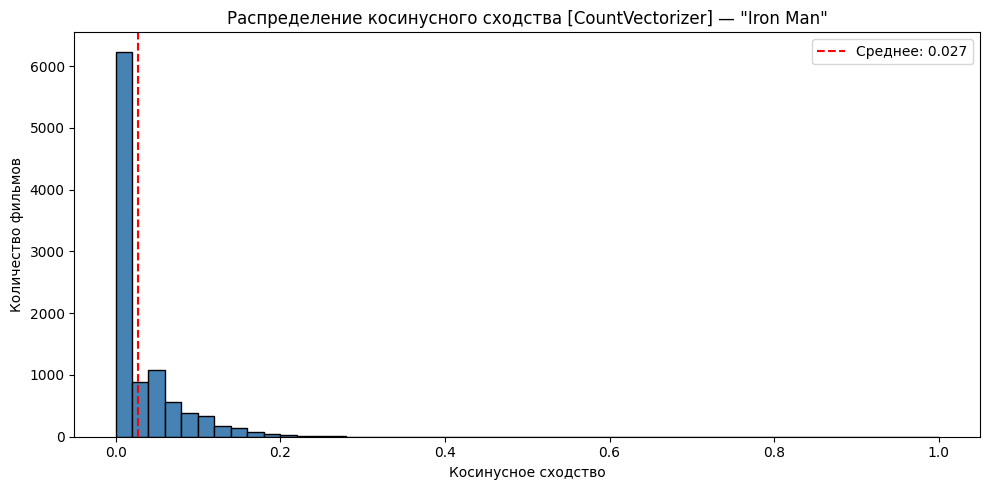

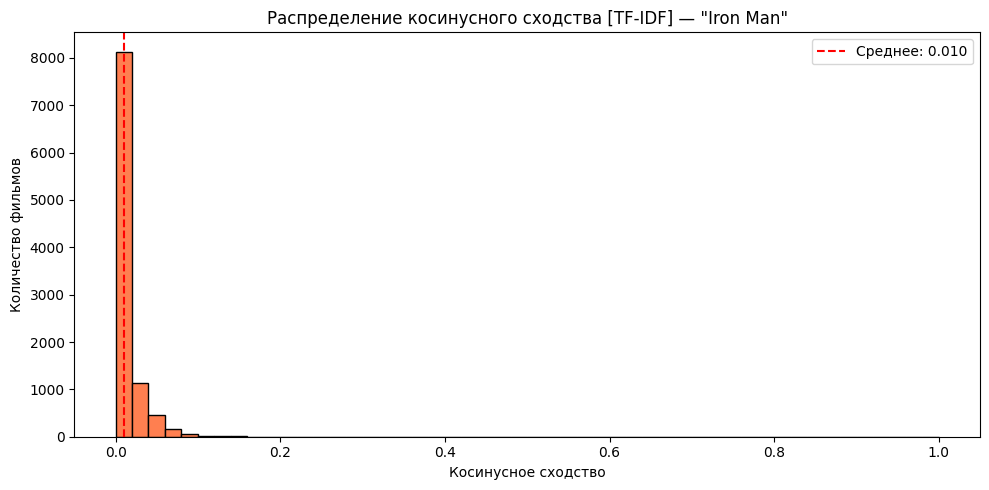

In [33]:
# ✅ ДОБАВЛЕНО 7: Визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# График 1: Распределение косинусного сходства (для обоих методов)
def plot_similarity_distribution(movie_title, method='count'):
    index  = new_data[new_data['title'] == movie_title].index[0]
    scores = similarity[index] if method == 'count' else similarity_tfidf[index]
    label  = 'CountVectorizer' if method == 'count' else 'TF-IDF'

    plt.figure(figsize=(10, 5))
    plt.hist(scores, bins=50, color='steelblue' if method == 'count' else 'coral', edgecolor='black')
    plt.title(f'Распределение косинусного сходства [{label}] — "{movie_title}"')
    plt.xlabel('Косинусное сходство')
    plt.ylabel('Количество фильмов')
    plt.axvline(x=scores.mean(), color='red', linestyle='--',
                label=f'Среднее: {scores.mean():.3f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'distribution_{method}.png', dpi=150)
    plt.show()



# Запускаем для обоих методов
plot_similarity_distribution("Iron Man", method='count')
plot_similarity_distribution("Iron Man", method='tfidf')


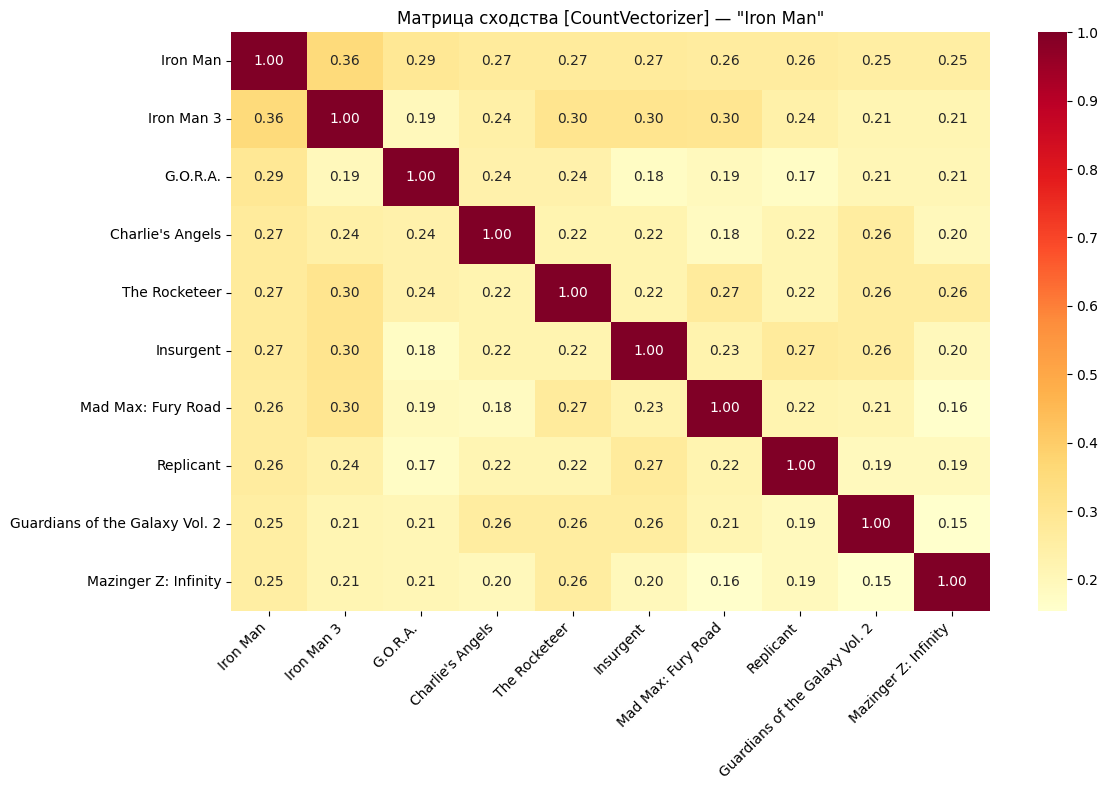

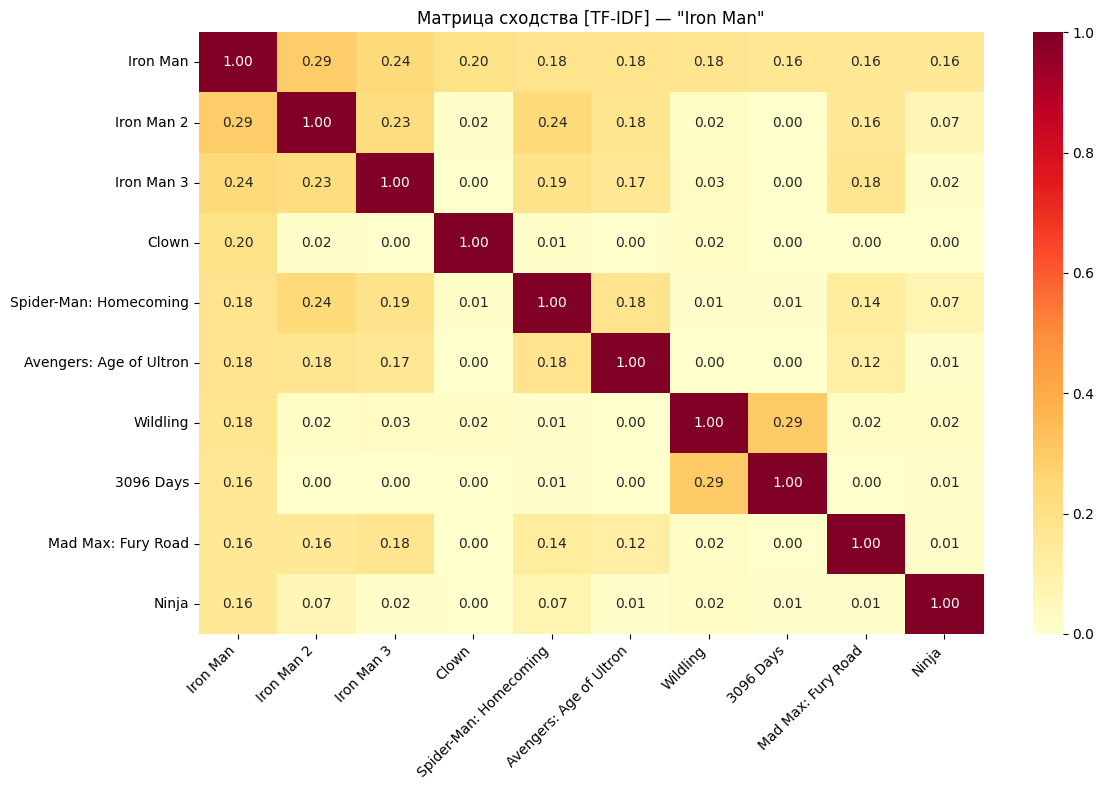

In [34]:
# График 2: Тепловая карта (для обоих методов)
def plot_heatmap(movie_title, method='count', n=10):
    index  = new_data[new_data['title'] == movie_title].index[0]
    sim    = similarity if method == 'count' else similarity_tfidf
    label  = 'CountVectorizer' if method == 'count' else 'TF-IDF'

    distances   = sorted(list(enumerate(sim[index])), reverse=True, key=lambda x: x[1])
    top_titles  = [new_data.iloc[i[0]].title for i in distances[:n]]
    top_indices = [i[0] for i in distances[:n]]
    sub_matrix  = sim[top_indices][:, top_indices]

    plt.figure(figsize=(12, 8))
    sns.heatmap(sub_matrix, annot=True, fmt='.2f',
                xticklabels=top_titles, yticklabels=top_titles,
                cmap='YlOrRd')
    plt.title(f'Матрица сходства [{label}] — "{movie_title}"')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'heatmap_{method}.png', dpi=150)
    plt.show()


plot_heatmap("Iron Man", method='count')
plot_heatmap("Iron Man", method='tfidf')

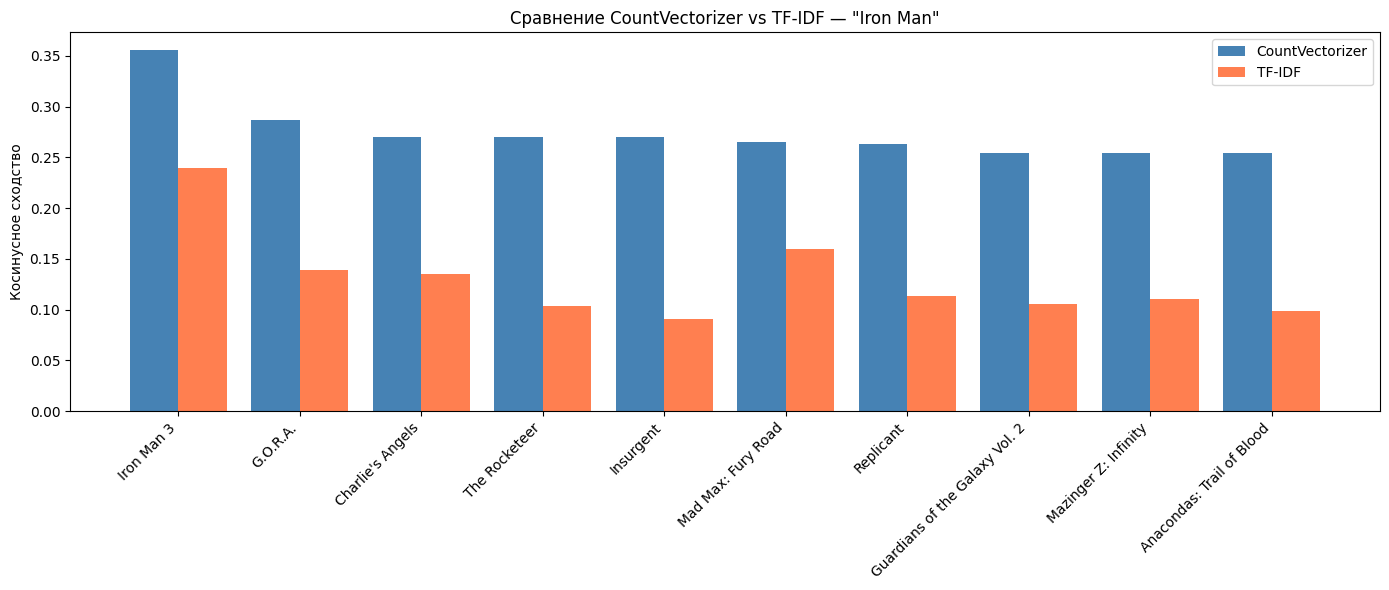

In [35]:
# График 3: Сравнение CountVectorizer vs TF-IDF
def plot_comparison(movie_title, n=10):
    index      = new_data[new_data['title'] == movie_title].index[0]
    dist_cv    = sorted(list(enumerate(similarity[index])),
                        reverse=True, key=lambda x: x[1])
    dist_tfidf = sorted(list(enumerate(similarity_tfidf[index])),
                        reverse=True, key=lambda x: x[1])

    titles_cv    = [new_data.iloc[i[0]].title for i in dist_cv[1:n+1]]
    scores_cv    = [round(i[1], 4) for i in dist_cv[1:n+1]]
    scores_tfidf = []

    for title in titles_cv:
        idx = new_data[new_data['title'] == title].index[0]
        scores_tfidf.append(round(similarity_tfidf[index][idx], 4))

    x = range(n)
    plt.figure(figsize=(14, 6))
    plt.bar([i - 0.2 for i in x], scores_cv,    width=0.4,
            label='CountVectorizer', color='steelblue')
    plt.bar([i + 0.2 for i in x], scores_tfidf, width=0.4,
            label='TF-IDF',         color='coral')
    plt.xticks(ticks=x, labels=titles_cv, rotation=45, ha='right')
    plt.ylabel('Косинусное сходство')
    plt.title(f'Сравнение CountVectorizer vs TF-IDF — "{movie_title}"')
    plt.legend()
    plt.tight_layout()
    plt.savefig('comparison.png', dpi=150)
    plt.show()

plot_comparison("Iron Man")

In [36]:
import pickle

In [37]:
pickle.dump(new_data,         open('movies_list.pkl',      'wb'))
pickle.dump(similarity,       open('similarity.pkl',       'wb'))
pickle.dump(similarity_tfidf, open('similarity_tfidf.pkl', 'wb'))

In [38]:
pickle.load(open('movies_list.pkl', 'rb'))

,id,title,tags
0,278,The Shawshank Redemption,frame in the 1940 for the doubl murder of hi w...
1,19404,Dilwale Dulhania Le Jayenge,"raj is a rich, carefree, happy-go-lucki second..."
2,238,The Godfather,"span the year 1945 to 1955, a chronicl of the ..."
3,424,Schindler's List,the true stori of how businessman oskar schind...
4,240,The Godfather: Part II,in the continu saga of the corleon crime famil...
...,...,...,...
9995,10196,The Last Airbender,"the stori follow the adventur of aang, a young..."
9996,331446,Sharknado 3: Oh Hell No!,the shark take bite out of the east coast when...
9997,13995,Captain America,"dure world war ii, a brave, patriot american s..."
9998,2312,In the Name of the King: A Dungeon Siege Tale,a man name farmer set out to rescu hi kidnap w...
